In [94]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas
from pathlib import Path
from scipy.spatial.distance import euclidean

In [ ]:
excel_stats = pandas.read_excel("RepoGitHub/Analyse-retinienne/analyse_verite_terrain.ods")

max_diam_x = max(max(excel_stats.Diam_x_Rouge), max(excel_stats.Diam_x_Jaune))
max_diam_y = max(max(excel_stats.Diam_y_Rouge), max(excel_stats.Diam_y_Jaune))
min_diam_x = min(min(excel_stats.Diam_x_Rouge), min(excel_stats.Diam_x_Jaune))
min_diam_y = min(min(excel_stats.Diam_y_Rouge), min(excel_stats.Diam_y_Jaune))

min_area = (min_diam_x / 2) * (min_diam_y / 2) * np.pi
max_area = (max_diam_x / 2) * (max_diam_y / 2) * np.pi

In [96]:
class LabelsDetection:

    """
    Classe pour la détection des annotations dans une image annotée.

    Attributes
    ----------
    image_path (str) : Nom ou chemin de l'image à traiter.
    labelled_image (np.ndarray) : Image annotée chargée en RGB.
    edges (np.ndarray) : Image binaire des bords obtenue par le prétraitement.
    detected_reds (list[np.ndarray]) : Différents contours rouges détectés dans l'image des bords.
    detected_yellows (list[np.ndarray]) : Différents contours jaunes détectés dans l'image des bords.
    best_red (np.ndarray) : Contour rouge correspondant le mieux à l'annotation rouge de l'image.
    best_yellow (np.ndarray) : Contour jaune correspondant le mieux à l'annotation jaune de l'image.
    best_center (tuple[int, int]) : Centre moyen des deux meilleurs contours.

    Methods
    -------
    preprocessing() : Prétraitement de l'image.
    contours_detection() : Détection des annotations dans l'image prétraitée.
    get_best_contours() : Trouve les contours correspondant le mieux aux annotations de l'image.
    show_results() : Affichage des résultats.
    """

    __stats = {"excel_stats": excel_stats, "min_area": min_area, "max_area": max_area}

    def __init__(self, image_path: str):
        """
        Constructeur de la classe.
        
        Parameters
        ----------
        image (str) : Nom ou chemin de l'image à traiter.
        """
        self.image_path = image_path
    
    def preprocessing(self) -> None:

        """
        Prétraitement de l'image.

        Charge l'image, la convertit en LUV et extrait ses bords.
        """

        self.labelled_image = cv2.imread(self.image_path, cv2.IMREAD_COLOR_RGB)
        image_luv = cv2.cvtColor(self.labelled_image, cv2.COLOR_RGB2LUV)
        self.edges = cv2.Canny(image_luv, threshold1=100, threshold2=200)


    def contours_detection(self) -> None:

        """
        Détecte les contours rouges et jaunes dans l'image prétraitée.
        """
        
        detected_contours, _ = cv2.findContours(self.edges, cv2.RETR_TREE, cv2.CHAIN_APPROX_NONE)
        suitable_contours = [detected_contour for detected_contour in detected_contours
                            if cv2.contourArea(detected_contour) >= self.__stats["min_area"] and cv2.contourArea(detected_contour) <= self.__stats["max_area"]]
        
        # Tri des contours par le rayon de leur cercle englobant
        suitable_contours.sort(key=lambda contour: cv2.minEnclosingCircle(contour)[1])

        # Partitionnement des contours entre rouges et jaunes
        radii = [cv2.minEnclosingCircle(contour)[1] for contour in suitable_contours]
        diffs = np.diff(radii)
        index_max_diff = np.argmax(diffs)
        
        detected_reds = suitable_contours[:index_max_diff + 1]
        detected_yellows = suitable_contours[index_max_diff + 1:]

        self.detected_reds = detected_reds
        self.detected_yellows = detected_yellows


    def get_best_contours(self) -> None:

        """
        Renvoie les meilleurs contours rouge et jaune : \
            ceux dont le centre est le plus proche du centre réel selon la distance euclidienne, ainsi que leur centre moyen.
        """

        reshaped_red_contours = [red_contour.reshape(-1, 2) for red_contour in self.detected_reds]
        red_centers = [(np.mean(reshaped_red_contour[:, 0]), np.mean(reshaped_red_contour[:, 1])) for reshaped_red_contour in reshaped_red_contours]

        reshaped_yellow_contours = [yellow_contour.reshape(-1, 2) for yellow_contour in self.detected_yellows]
        yellow_centers = [(np.mean(reshaped_yellow_contour[:, 0]), np.mean(reshaped_yellow_contour[:, 1])) for reshaped_yellow_contour in reshaped_yellow_contours]

        image_name_for_dataframe_access = Path(self.image_path).stem
        true_center = (self.__stats["excel_stats"]["pos_centre_x"].loc[self.__stats["excel_stats"]["Nom Image"] == image_name_for_dataframe_access],
                       self.__stats["excel_stats"]["pos_centre_y"].loc[self.__stats["excel_stats"]["Nom Image"] == image_name_for_dataframe_access])
        true_center = (int(true_center[0].iloc[0]), int(true_center[1].iloc[0]))

        red_centers_distances = [euclidean(red_center, true_center) for red_center in red_centers]
        yellow_centers_distances = [euclidean(yellow_center, true_center) for yellow_center in yellow_centers]

        min_red_index, min_yellow_index = np.argmin(red_centers_distances), np.argmin(yellow_centers_distances)

        best_red, best_yellow = self.detected_reds[min_red_index], self.detected_yellows[min_yellow_index]
        best_cx = int(np.round((red_centers[min_red_index][0] + yellow_centers[min_yellow_index][0] ) / 2))
        best_cy = int(np.round((red_centers[min_red_index][1] + yellow_centers[min_yellow_index][1] ) / 2))
        best_center = (best_cx, best_cy)

        self.best_red = best_red
        self.best_yellow = best_yellow
        self.best_center = best_center


    def show_results(self) -> None:

        """
        Affiche les résultats obtenus par le pipeline.
        """

        fig = plt.figure(figsize=(14, 10))
        axes = fig.subplots(2, 2)

        axes[0][0].imshow(self.labelled_image)
        axes[0][0].set_title("Image annotée")
        axes[0][0].set_axis_off()

        mask = np.zeros(self.labelled_image.shape)
        cv2.drawContours(image=mask, contours=[self.best_red, self.best_yellow], contourIdx=-1, color=(255, 255, 255), thickness=2)
        axes[0][1].imshow(mask)
        axes[0][1].scatter(self.best_center[0], self.best_center[1], c="white", marker="+")
        axes[0][1].set_title("Masque des annotations obtenu et centre moyen")
        axes[0][1].set_axis_off()

        _, red_radius = cv2.minEnclosingCircle(self.best_red)
        red_radius = int(np.round(red_radius))
        _, yellow_radius = cv2.minEnclosingCircle(self.best_yellow)
        yellow_radius = int(np.round(yellow_radius))
        copy = np.copy(self.labelled_image)
        cv2.circle(img=copy, center=self.best_center, radius=red_radius, color=(255, 0, 0), thickness=2)
        cv2.circle(img=copy, center=self.best_center, radius=yellow_radius, color=(255, 255, 0), thickness=2)
        axes[1][0].imshow(copy)
        axes[1][0].set_title("Cercles englobants des annotations")
        axes[1][0].set_axis_off()

        cropped_image = self.labelled_image[self.best_center[1]-yellow_radius-25 : self.best_center[1]+yellow_radius+25,
                                            self.best_center[0]-yellow_radius-25 : self.best_center[0]+yellow_radius+25]
        axes[1][1].imshow(cropped_image)
        axes[1][1].set_title("Région d'intérêt")
        axes[1][1].set_axis_off()
        plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


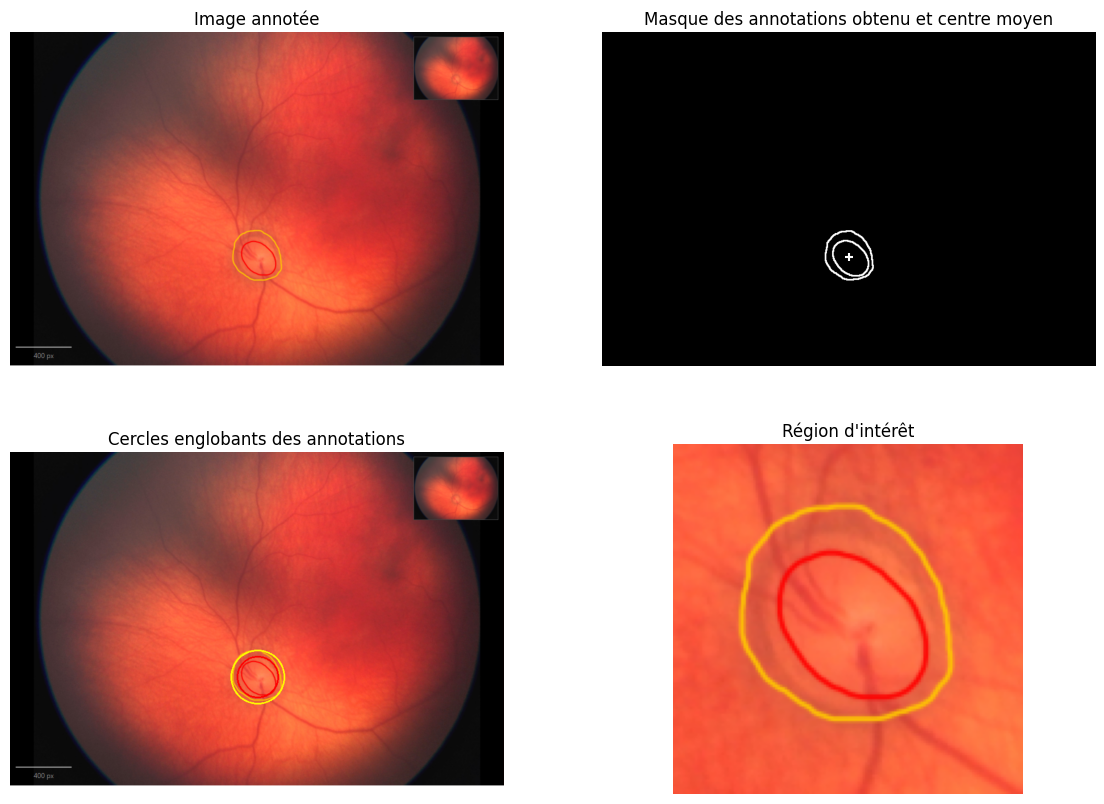

In [97]:
# Test Pipeline
labels_detection = LabelsDetection("labelled_images/Caen/AMI-234833-OG.tif")
labels_detection.preprocessing()
labels_detection.contours_detection()
labels_detection.get_best_contours()
labels_detection.show_results()

In [98]:
p_caen = Path("labelled_images/Caen/")
fails = []

for image_path in p_caen.iterdir():
    detection = LabelsDetection(image_path)
    detection.preprocessing()
    detection.contours_detection()
    detection.get_best_contours()
    if len(detection.detected_reds) == 0 or len(detection.detected_yellows) == 0:
        fails += [image_path.name]

if len(fails) > 0:
    print("Images problématiques :\n", fails)
else:
    print("Detection OK sur toutes les images.")

Detection OK sur toutes les images.
